In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import shutil
import cv2

# Add the src directory to the path. TEMPORARY FIX
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.data_processing.dataset_loader import CoastData

In [ ]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_v1.0.0/"))

registered_path =  os.path.abspath(os.path.join(os.getcwd(), "../../../data/registered_images/"))
sclabels_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_v1.0.0/"))

# # Test with a single station. Differents stations: agrelo, cies, cadiz, samarador, arenaldentem
# data = CoastData(sclabels_path, name="agrelo")
destination_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_registered_v1.0.0/images/"))

stations = ["agrelo", "arenaldentem", "cadiz", "cies", "samarador"]
# stations = ["arenaldentem"]

for station in stations:
    print(f"Processing station: {station}")
    data = CoastData(sclabels_path, name=station)
    filtered_data, files_name = data.get_images()
    print(f"{len(filtered_data)} images found.")
    print(f"{len(files_name)} files found.")


    path = os.path.join(registered_path, f"Registered_{station}", "Registered")

    # get list of folders
    folders = sorted(os.listdir(path))

    for folder in folders:
        print(f"Processing folder: {folder}")
        folder_path = os.path.join(path, folder)

        # get images in folder
        images = sorted(os.listdir(folder_path))

        for i, image_name in enumerate(images):
            if image_name in files_name:
                index_in_files = files_name.index(image_name)
                image_path = os.path.join(folder_path, image_name)
                aux_destination_path = os.path.join(destination_path, filtered_data[index_in_files])
                # copy image to another folder
                shutil.copy(image_path, aux_destination_path)
            else:
                print(f"Image {image_name} not found in files_name.")

Processing station: agrelo
CoastData: agrelo - 244 images
244 images found.
244 files found.
Processing folder: 2018
Processing folder: 2019
Image 1548495720.Sat.Jan.26_10_42_00.CET.2019.agrelo.snap.CoastSnapGalicia_registered.jpg not found in files_name.
Image 1550675700.Wed.Feb.20_16_15_00.CET.2019.agrelo.snap.LiberKekesbull_registered.jpg not found in files_name.
Image 1550934240.Sat.Feb.23_16_04_00.CET.2019.agrelo.snap.coastsnapgz_registered.jpg not found in files_name.
Image 1568653020.Mon.Sep.16_17_57_00.CET.2019.agrelo.snap.rglezvill_registered.jpg not found in files_name.
Image 1572958920.Tue.Nov.05_14_02_00.CET.2019.agrelo.snap.CentolodaRia_registered.jpg not found in files_name.
Processing folder: 2020
Image 1578851040.Sun.Jan.12_18_44_00.CET.2020.agrelo.snap.coastsnapgz_registered.jpg not found in files_name.
Image 1578851040.Sun.Jan.12_18_44_00.CET.2020.agrelo.timex.ritaglez_registered.jpg not found in files_name.
Image 1589215680.Mon.May.11_17_48_00.CET.2020.agrelo.snap.Am

In [5]:
new_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_registered_v1.0.0/"))

data = CoastData(new_path, name="arenaldentem")
data = data.get_images_and_shooreline_coords()

# print(data)

CoastData: arenaldentem - 40 images


Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1661756929.Mon.Aug.29_08_08_49.CET.2022.arenaldentem.image.jpg


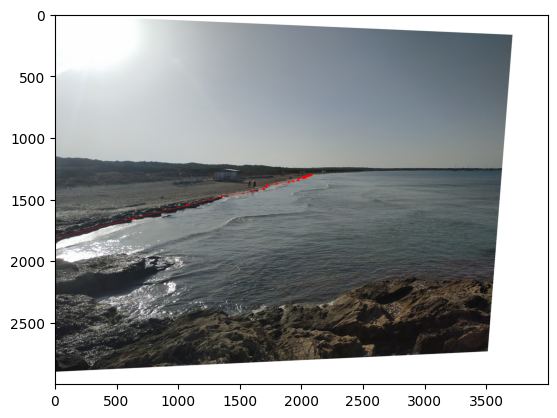

Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1663582740.Mon.Sep.19_11_19_00.CET.2022.arenaldentem.image.jpg


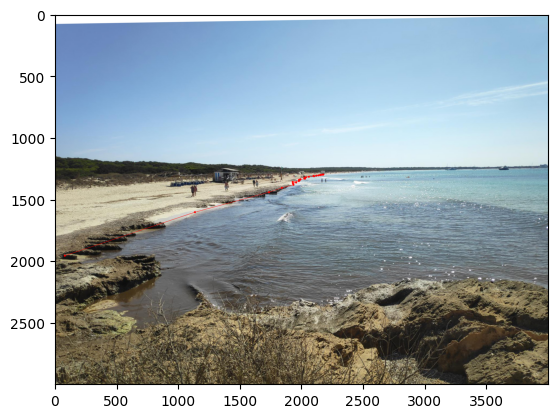

Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1664092920.Sun.Sep.25_09_02_00.CET.2022.arenaldentem.image.jpg


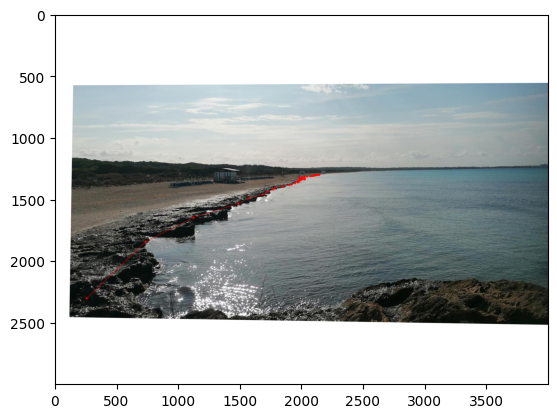

Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1664373960.Wed.Sep.28_15_06_00.CET.2022.arenaldentem.image.jpg


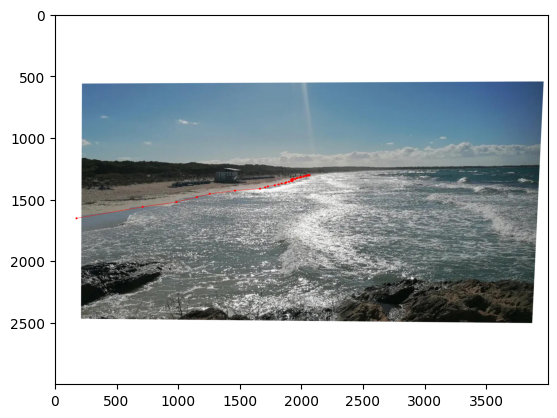

Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1664951040.Wed.Oct.05_07_24_00.CET.2022.arenaldentem.image.jpg


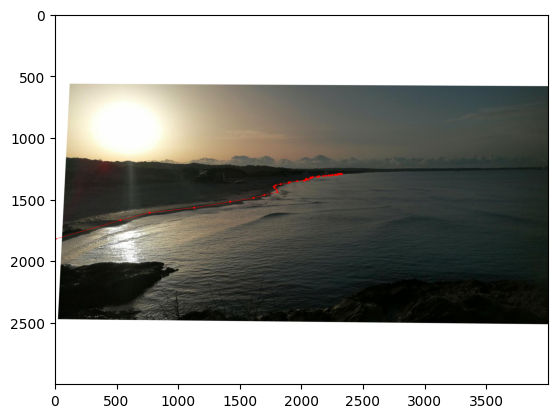

Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1666161300.Wed.Oct.19_07_35_00.CET.2022.arenaldentem.image.jpg


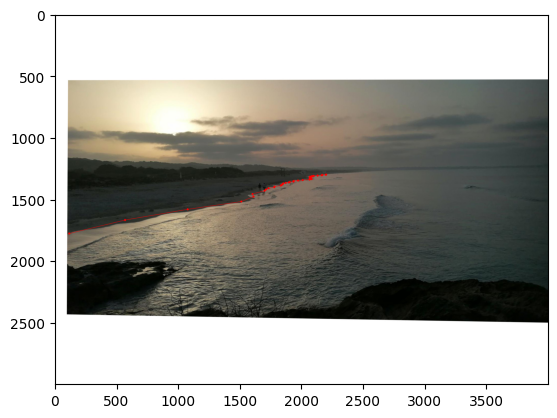

Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1666261080.Thu.Oct.20_11_18_00.CET.2022.arenaldentem.image.jpg


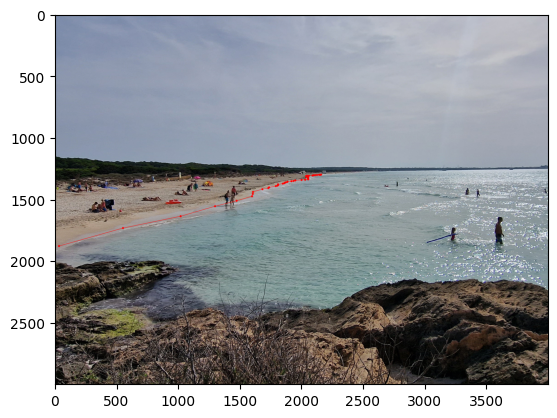

Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1666335060.Fri.Oct.21_07_51_00.CET.2022.arenaldentem.image.jpg


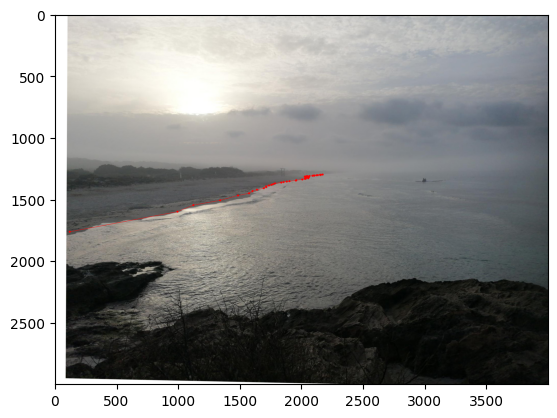

Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1666885860.Thu.Oct.27_16_51_00.CET.2022.arenaldentem.image.jpg


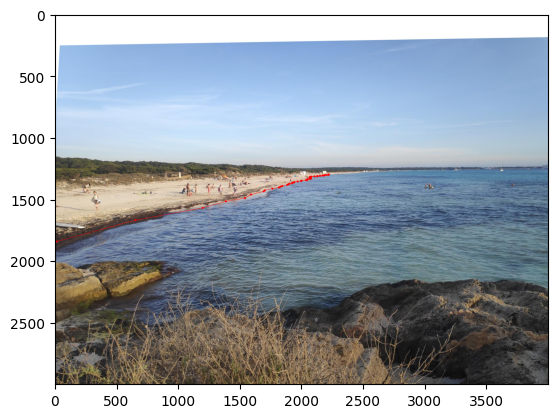

Image: c:\Users\josep\Documents\SOCIB\Shoreline-extraction\data\SCLabels_oblique_registered_v1.0.0\images\1666886080.Thu.Oct.27_16_54_40.CET.2022.arenaldentem.image.jpg


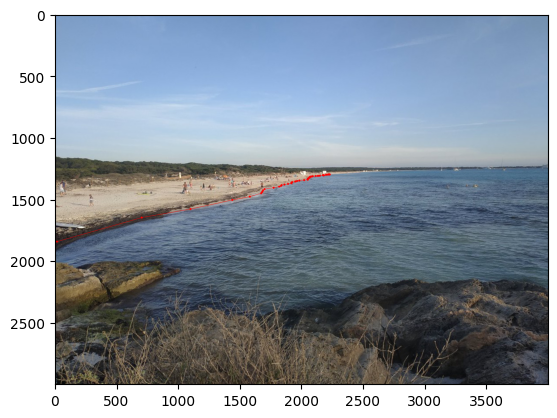

In [6]:
for i in range(10):
    print(f"Image: {data[i]['image']}")
    img = cv2.imread(data[i]['image'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    coords = data[i]['shoreline_coords']
    height, width, _ = img.shape

    points = []
    for u, v in zip(coords["u"], coords["v"]):
        points.append((int(u), height - int(v)))

        cv2.circle(img, (int(u), height - int(v)), 5, (255, 0, 0), 5)
    
    cv2.polylines(img, [np.array(points)], isClosed=False, color=(255, 0, 0), thickness=2)

    plt.imshow(img)
    plt.show()

In [ ]:
new_path = "/LOCALDATA/josep/Shoreline-extraction/data/SCLabels_oblique_registered_v1.0.0/"

data = CoastData(new_path, name="arenaldentem")
data = data.get_images_and_shooreline_coords()

In [ ]:
img = cv2.imread(data[1]['image'])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.show()